In [81]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [82]:
df = pd.read_csv("/content/G1.csv")

In [83]:
df.head()

,Response_ID,Timestamp,Age,Gender,Occupation_Status,Country_Region,Monthly_Income_Range,Shop_Most_Where,Online_Shopping_Frequency,Preferred_Platform,...,Return_Frequency,Avg_Monthly_Spend_NonEssentials,Preferred_Payment_Method,Uses_BNPL_Installments,Online_Shopping_Satisfaction_Score,Trust_In_Online_Reviews_Score,Regret_After_Purchase_Frequency,Reason_Prefer_Online,Reason_Prefer_InStore,Best_Shopping_Mode
0,1,01/08/2026 12:30:25,20,Male,NaN,Philippines,"Under $1,000",Equal mix,Often,Physical stores,...,Never,Under $50,Digital wallet,"Yes, occasionally",6.0,7.0,2.0,More variety,No delivery wait,Online
1,2,21/06/2026 13:52:02,24,Male,Employed part-time,Brazil,"Under $1,000",In-store only,Often,Local e-commerce,...,Often,Under $50,Digital wallet,"No, never",5.0,8.0,3.0,NaN,Try product before buying,Offline
2,3,15/08/2026 04:24:18,22,Female,Student,India,"Under $1,000",Equal mix,Always,Local e-commerce,...,Sometimes,$150-300,Credit Card,"No, never",7.0,6.0,2.0,Better prices,Trust,Online
3,4,23/06/2026 21:24:21,20,Male,Student,NaN,"Under $1,000",In-store only,Occasionally,Brand websites,...,Never,Under $50,Debit Card,"No, never",8.0,7.0,3.0,Better prices,Try product before buying,Equal / both
4,5,20/08/2026 16:24:47,41,Male,Employed full-time,United States,"$1,000-3,000",Equal mix,Occasionally,NaN,...,Sometimes,$50-150,Debit Card,"No, never",6.0,8.0,2.0,Convenience,Trust,Equal / both


In [84]:
print('Shape:',df.shape)

Shape: (500, 30)


In [85]:
print(df.columns)
df.columns = df.columns.str.lower()

Index(['Response_ID', 'Timestamp', 'Age', 'Gender', 'Occupation_Status',
       'Country_Region', 'Monthly_Income_Range', 'Shop_Most_Where',
       'Online_Shopping_Frequency', 'Preferred_Platform', 'Primary_Device',
       'Top_Spending_Category', 'Review_Influence_Score',
       'Social_Ads_Influence_Score', 'Price_Comparison_Frequency',
       'Discount_Importance_Score', 'Follows_Brands_On_Social',
       'Likely_To_Buy_After_Ad_Score', 'Makes_Shopping_List',
       'Impulse_Purchase_Frequency', 'Return_Frequency',
       'Avg_Monthly_Spend_NonEssentials', 'Preferred_Payment_Method',
       'Uses_BNPL_Installments', 'Online_Shopping_Satisfaction_Score',
       'Trust_In_Online_Reviews_Score', 'Regret_After_Purchase_Frequency',
       'Reason_Prefer_Online', 'Reason_Prefer_InStore', 'Best_Shopping_Mode'],
      dtype='object')


In [86]:
df.dtypes

,0
response_id,int64
timestamp,object
age,object
gender,object
occupation_status,object
country_region,object
monthly_income_range,object
shop_most_where,object
online_shopping_frequency,object
preferred_platform,object


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 30 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   response_id                         500 non-null    int64  
 1   timestamp                           500 non-null    object 
 2   age                                 478 non-null    object 
 3   gender                              484 non-null    object 
 4   occupation_status                   479 non-null    object 
 5   country_region                      480 non-null    object 
 6   monthly_income_range                479 non-null    object 
 7   shop_most_where                     484 non-null    object 
 8   online_shopping_frequency           481 non-null    object 
 9   preferred_platform                  486 non-null    object 
 10  primary_device                      492 non-null    object 
 11  top_spending_category               476 non-n

In [88]:
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object','category']).columns


print('Numerical columns:')
print(num_cols.to_list())
print('\nCategorical columns:')
print(cat_cols.to_list())



Numerical columns:
['response_id', 'age', 'review_influence_score', 'social_ads_influence_score', 'price_comparison_frequency', 'discount_importance_score', 'likely_to_buy_after_ad_score', 'impulse_purchase_frequency', 'online_shopping_satisfaction_score', 'trust_in_online_reviews_score', 'regret_after_purchase_frequency']

Categorical columns:
['gender', 'occupation_status', 'country_region', 'monthly_income_range', 'shop_most_where', 'online_shopping_frequency', 'preferred_platform', 'primary_device', 'top_spending_category', 'follows_brands_on_social', 'makes_shopping_list', 'return_frequency', 'avg_monthly_spend_nonessentials', 'preferred_payment_method', 'uses_bnpl_installments', 'reason_prefer_online', 'reason_prefer_instore', 'best_shopping_mode']


In [89]:
df.isnull().sum()

,0
response_id,0
timestamp,336
age,30
gender,16
occupation_status,21
country_region,20
monthly_income_range,21
shop_most_where,16
online_shopping_frequency,19
preferred_platform,14


In [90]:
df.duplicated().sum()
#no duplicated rows

np.int64(0)

In [91]:
df.describe()

,response_id,timestamp,age,review_influence_score,social_ads_influence_score,price_comparison_frequency,discount_importance_score,likely_to_buy_after_ad_score,impulse_purchase_frequency,online_shopping_satisfaction_score,trust_in_online_reviews_score,regret_after_purchase_frequency
count,500.000000,164,470.000000,485.000000,479.000000,474.000000,477.000000,475.000000,484.000000,457.000000,450.000000,448.000000
mean,250.500000,2026-06-25 02:49:51.304877824,25.019149,3.053608,3.079332,4.139241,3.821803,3.016842,2.590909,7.126915,6.160000,2.187500
min,1.000000,2026-01-07 05:06:37,16.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000
25%,125.750000,2026-04-07 04:33:47.500000,20.000000,2.000000,2.000000,4.000000,3.000000,2.000000,2.000000,6.000000,5.000000,1.000000
50%,250.500000,2026-07-07 13:43:24.500000,22.000000,3.000000,3.000000,4.000000,4.000000,3.000000,2.000000,7.000000,6.000000,2.000000
75%,375.250000,2026-09-15 19:03:30,30.000000,4.000000,4.000000,5.000000,5.000000,4.000000,3.000000,8.000000,7.000000,3.000000
max,500.000000,2026-12-08 23:34:43,50.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,10.000000,10.000000,4.000000
std,144.481833,NaN,7.515276,1.128707,1.228144,0.943219,0.989284,1.109857,1.162741,1.592636,1.918425,0.902705


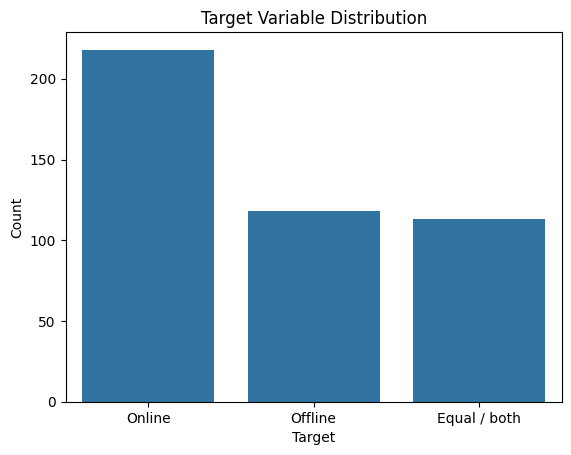

In [92]:
sns.countplot(data=df, x='best_shopping_mode')
plt.title('Target Variable Distribution')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

#most customers prefer online shopping

Analytical Questions - Answers

1. No. This is an imbalanced dataset.

2.

3. This is a scenerio based problem statement. It has 500 rows and 30 columns. From this we can understand most customers prefer online shopping.

EDA

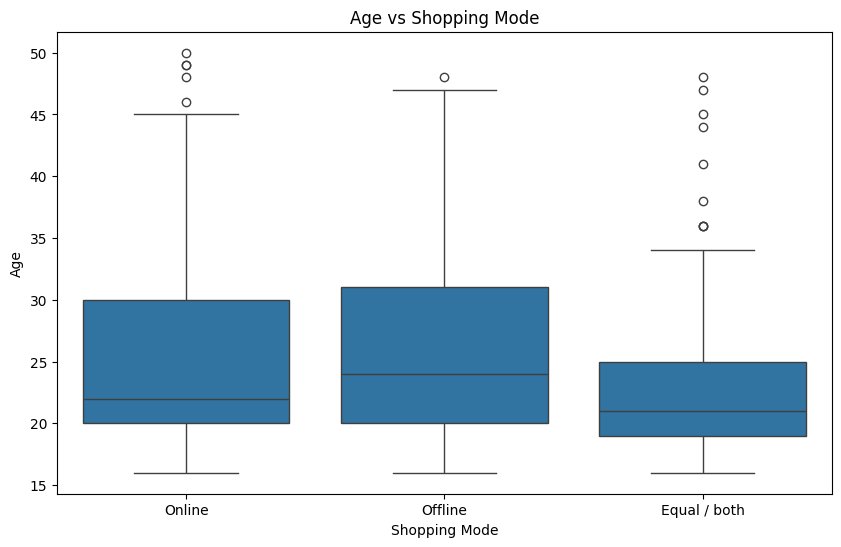

In [93]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='best_shopping_mode',
    y='age'
)

plt.title('Age vs Shopping Mode')
plt.xlabel('Shopping Mode')
plt.ylabel('Age')
plt.show()

#most of the customers are mid-aged.

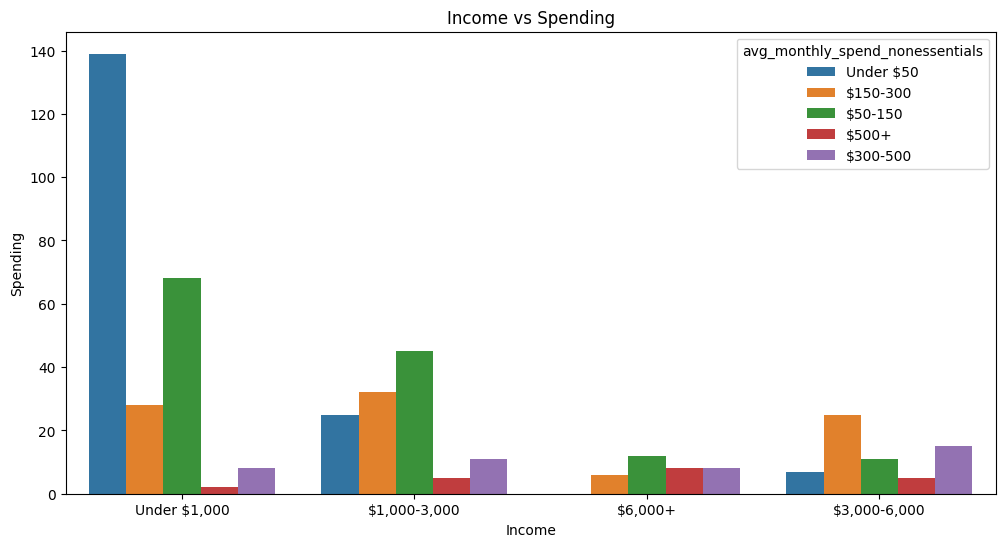

In [94]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x='monthly_income_range',
    hue='avg_monthly_spend_nonessentials',
)

plt.title('Income vs Spending')
plt.xlabel('Income')
plt.ylabel('Spending')
plt.show()

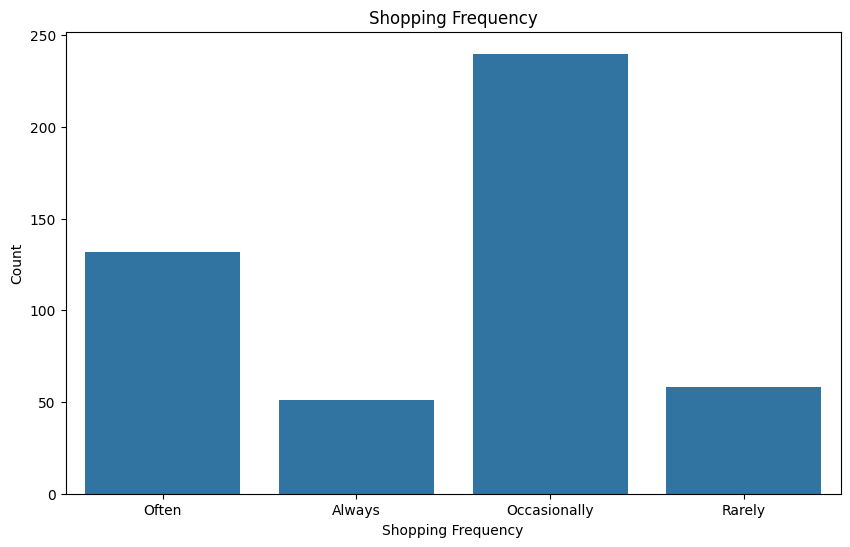

In [95]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='online_shopping_frequency'
)

plt.title('Shopping Frequency')
plt.xlabel('Shopping Frequency')
plt.ylabel('Count')
plt.show()

#most of the customers are shopping occasionally

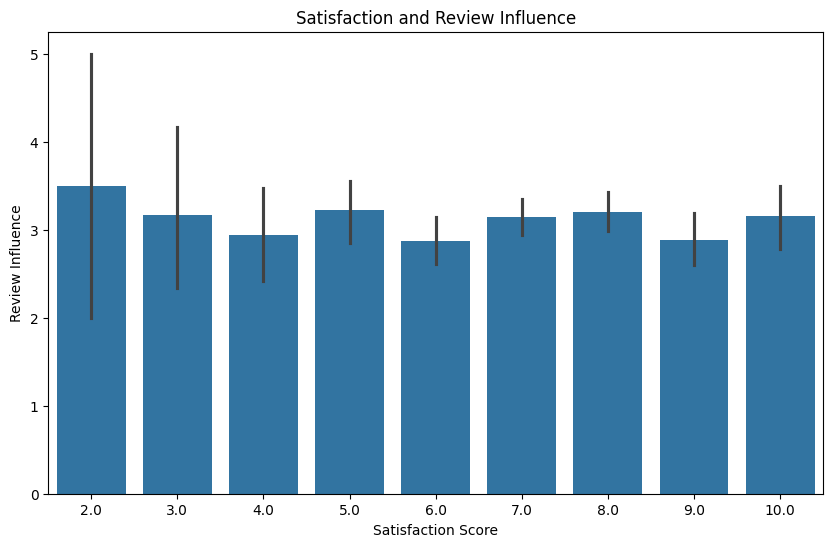

In [96]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x='online_shopping_satisfaction_score',
    y='review_influence_score'
)

plt.title('Satisfaction and Review Influence')
plt.xlabel('Satisfaction Score')
plt.ylabel('Review Influence')
plt.show()

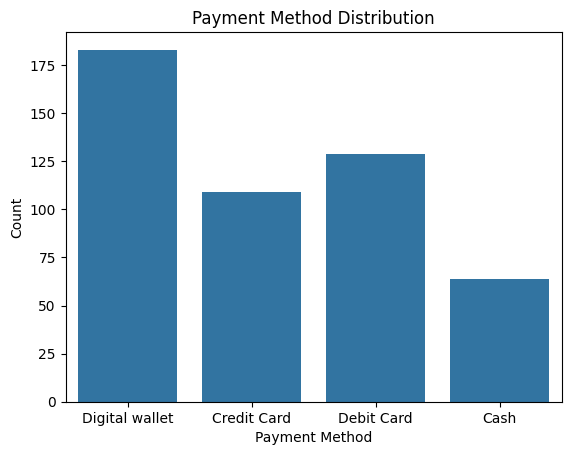

In [97]:
sns.countplot(data=df, x='preferred_payment_method')
plt.title('Payment Method Distribution')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.show()

#most of the customers using digital wallet

Data Preprocessing

In [98]:
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())
df.isna().sum()

,0
response_id,0
timestamp,336
age,0
gender,16
occupation_status,21
country_region,20
monthly_income_range,21
shop_most_where,16
online_shopping_frequency,19
preferred_platform,14


In [99]:
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])
df[cat_cols].isna().sum()

,0
gender,0
occupation_status,0
country_region,0
monthly_income_range,0
shop_most_where,0
online_shopping_frequency,0
preferred_platform,0
primary_device,0
top_spending_category,0
follows_brands_on_social,0


In [100]:
df.duplicated().sum()
# no duplicated rows

np.int64(0)

In [101]:
x=df.drop(columns= "best_shopping_mode")
y = df["best_shopping_mode"]

In [102]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,stratify=y)

In [107]:
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [ ]:
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [108]:
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', num_transformer, num_cols),
        ('categorical', cat_transformer, cat_cols)
    ]
)

In [109]:
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

In [110]:
print(x_train_processed.shape)
print(x_test_processed.shape)

(400, 90)
(100, 90)


Model

In [120]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(x_train_processed,y_train)
lr_pred = lr.predict(x_test_processed)

In [125]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred, average='weighted'))
print("Recall:", recall_score(y_test, lr_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, lr_pred, average='weighted'))

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_pred))

Accuracy: 0.57
Precision: 0.5541827956989248
Recall: 0.57
F1 Score: 0.5574876847290641

Classification Report:
              precision    recall  f1-score   support

Equal / both       0.15      0.14      0.14        22
     Offline       0.61      0.46      0.52        24
      Online       0.69      0.80      0.74        54

    accuracy                           0.57       100
   macro avg       0.48      0.46      0.47       100
weighted avg       0.55      0.57      0.56       100


Confusion Matrix:
[[ 3  4 15]
 [ 9 11  4]
 [ 8  3 43]]


In [127]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state = 42)

dt.fit(x_train_processed,y_train)
dt_pred = dt.predict(x_test_processed)

In [128]:
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred, average='weighted'))
print("Recall:", recall_score(y_test, dt_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, dt_pred, average='weighted'))

print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

Accuracy: 0.56
Precision: 0.5541353383458647
Recall: 0.56
F1 Score: 0.5562522522522523

Classification Report:
              precision    recall  f1-score   support

Equal / both       0.18      0.18      0.18        22
     Offline       0.52      0.46      0.49        24
      Online       0.72      0.76      0.74        54

    accuracy                           0.56       100
   macro avg       0.47      0.47      0.47       100
weighted avg       0.55      0.56      0.56       100


Confusion Matrix:
[[ 4  7 11]
 [ 8 11  5]
 [10  3 41]]


In [129]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators = 5,
                            random_state = 42)

rf.fit(x_train_processed,y_train)
rf_pred = rf.predict(x_test_processed)

In [130]:
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred, average='weighted'))
print("Recall:", recall_score(y_test, rf_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, rf_pred, average='weighted'))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Accuracy: 0.51
Precision: 0.49917241379310345
Recall: 0.51
F1 Score: 0.5038302277432712

Classification Report:
              precision    recall  f1-score   support

Equal / both       0.20      0.18      0.19        22
     Offline       0.50      0.46      0.48        24
      Online       0.62      0.67      0.64        54

    accuracy                           0.51       100
   macro avg       0.44      0.44      0.44       100
weighted avg       0.50      0.51      0.50       100


Confusion Matrix:
[[ 4  6 12]
 [ 3 11 10]
 [13  5 36]]


In [131]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(x_train_processed,y_train)
svm_pred = svm.predict(x_test_processed)

In [132]:
print("Accuracy:", accuracy_score(y_test, svm_pred))
print("Precision:", precision_score(y_test, svm_pred, average='weighted'))
print("Recall:", recall_score(y_test, svm_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, svm_pred, average='weighted'))

print("\nClassification Report:")
print(classification_report(y_test, svm_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, svm_pred))

Accuracy: 0.53
Precision: 0.39295454545454545
Recall: 0.53
F1 Score: 0.419887323943662

Classification Report:
              precision    recall  f1-score   support

Equal / both       0.00      0.00      0.00        22
     Offline       0.33      0.08      0.13        24
      Online       0.58      0.94      0.72        54

    accuracy                           0.53       100
   macro avg       0.30      0.34      0.28       100
weighted avg       0.39      0.53      0.42       100


Confusion Matrix:
[[ 0  3 19]
 [ 4  2 18]
 [ 2  1 51]]


Hyperparameter Tuning

In [134]:
from sklearn.model_selection import GridSearchCV

param_grid={
    'n_estimators':[50,100,150],
    'max_depth':[None,10,20]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1'
)

grid_search.fit(x_train_processed,y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(x_test_processed)

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
    result, _ = _get

{'max_depth': None, 'n_estimators': 50}
nan


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
    result, _ = _get

In [139]:
import pickle

with open('model.pkl','wb') as file:
  pickle.dump(best_rf,file)

In [140]:
with open('preprocessor.pkl','wb') as file:
  pickle.dump(preprocessor,file)

In [141]:
feature_columns = df.columns.tolist()

with open('feature_columns.pkl','wb') as file:
  pickle.dump(feature_columns,file)